In [1]:
from sklearn.neural_network import MLPRegressor
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import clone
import Feature_Engineering as FE
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\ProgramData\Minic

In [ ]:
data = FE.data
data_reg = data[(data['INGRESO'] == 1) & (data["PROP"].notna())]
y_reg = data_reg['logP47T']
excluir_cols = {'logP47T', 'Q','INGRESO', 'CODUSU', 'P47T', 'P21', 'T_VI', 'V12_M', 'V2_M', 'V3_M', 'V5_M', 'TOT_P12', 'PP08D1', 
                'logP21', 'logT_VI', 'logV12_M', 'logV2_M', 'logV3_M', 'logV5_M', 'logTOT_P12', 'logPP08D1','ANO4','TRIMESTRE', 'INGRESO_NLB','INGRESO_JUB','INGRESO_SBS'}
X_reg = data_reg.drop(columns=excluir_cols)
candidate_cols = X_reg.columns.difference(excluir_cols)

In [9]:
#Multi Layer Perceptron

feature_cols = candidate_cols
target_col = "logP47T"

X = data_reg[feature_cols]
y = data_reg[target_col].values

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preproc = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
], remainder='drop')


#Pipeline: preprocesamiento + MLPRegressor
pipe = Pipeline([
    ('preproc', preproc),
    ('reg', MLPRegressor(
        activation='relu',
        solver='adam',
        random_state=42,
        # el resto se ajusta vía grid
    ))
])

# Grilla de hiperparámetros
param_grid = {
    # Arquitectura (capas y neuronas)
    'reg__hidden_layer_sizes': [
        (64, 32),
        (128, 64),
        (64, 64, 32),
        (128, 128)
    ],
    # Tamaño de batch y épocas
    'reg__batch_size': [64, 128],
    'reg__max_iter': [100, 200]
}

# Split y búsqueda (CV)
X_train_test, X_val, y_train_test, y_val = train_test_split(X_reg, y_reg, test_size=0.10, random_state=42) #Separo 10% para validacion
X_train, X_test, y_train, y_test = train_test_split(X_train_test, y_train_test, test_size=2/9, random_state=42) #Separo 20% total para test, 70% Train
print(data_reg.shape)


(328445, 79)


In [ ]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',   
    n_jobs=-1,
    refit=True,
    verbose=0
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_test_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2  = r2_score(y_test, y_test_pred)

print("\n=== Mejor configuración encontrada ===")
print(grid.best_params_)
print("\n=== Métricas en test ===")
print(f"Test MSE: {test_mse:.6f} | Test R²: {test_r2:.6f}")

c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\Miniconda3\envs\env_jupyter\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5) reached and the optimization hasn't converged yet.
  warnings.warn(


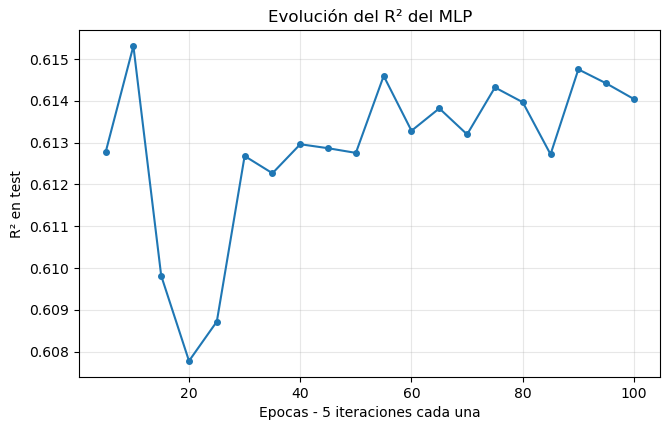

In [26]:
# Grafico R² por época (cada 5 épocas reales)

# 1) Preprocesamiento ya aprendido
preproc_fitted = best_model.named_steps['preproc']
X_train_t = preproc_fitted.transform(X_train)
X_test_t  = preproc_fitted.transform(X_test)

# 2) Tomo la mejor MLP encontrada (mismos hiperparametros), pero sin entrenar
reg_best_fitted = best_model.named_steps['reg']
reg_epoch = clone(reg_best_fitted)

EPOCH_SIZE = 5     # cada época = 5 iteraciones
reg_epoch.set_params(
    max_iter=EPOCH_SIZE,   # Entreno 5 iteraciones por llamada a fit()
    warm_start=True, 
    early_stopping=False,
    shuffle=False
)

# 3) Iteraciones totales que tenía la mejor configuracion
total_iters = reg_best_fitted.get_params()['max_iter']

# 4) Entrenar de a bloques de 5 iteraciones
r2_list = []
epoch_list = []

current_iter = 0

while current_iter < total_iters:

    reg_epoch.fit(X_train_t, y_train)

    current_iter += EPOCH_SIZE #Cada epoca son 5 iteraciones
    if current_iter > total_iters:
        current_iter = total_iters

    y_pred_epoch = reg_epoch.predict(X_test_t)
    r2_now = r2_score(y_test, y_pred_epoch)

    r2_list.append(r2_now)
    epoch_list.append(current_iter)

# 5) Graficar R² vs epocas de 5 iteraciones
plt.figure(figsize=(7.5, 4.5))
plt.plot(epoch_list, r2_list, marker='o', ms=4, lw=1.5)
plt.xlabel("Epocas - 5 iteraciones cada una")
plt.ylabel("R² en test")
plt.title("Evolución del R² del MLP")
plt.grid(True, alpha=0.3)
plt.savefig("R2_por_Epochs_MLP")
plt.show()
